# GAP Subgraphing Exploration — Candidate Adversary Profiles

**Author:** Marc Labouchardiere (23857377) · **Supervisor:** Dr Jin B. Hong
**Date:** 2026-04-17 · **Thesis context:** MTDShield — adaptive MTD for dynamic networks.

## Why this notebook exists

Sub-problem 1 of the thesis is to define **defensible adversary profiles** that parameterise an adaptive MTD simulator. A profile is a subgraph of the Generalised Attack Profile (GAP) — a selection of techniques + dependency edges that represents a coherent class of adversary behaviour.

A prior notebook ([2026-04-16_MTDSim_ATTACKMotivationExploration.ipynb](2026-04-16_MTDSim_ATTACKMotivationExploration.ipynb)) attempted to subgraph the GAP by **STIX motivation** (espionage / financial / destructive / …). That approach failed because MITRE ATT&CK encodes *what* adversaries did, not *why*: the STIX `primary_motivation` field is unpopulated across all 187 Group objects and all 52 Campaign objects. Motivation only lives in free-text `description` prose and is therefore not MITRE-canonical, not structured, and has no authoritative external source to validate against (CTI attribution bias — Mandiant, ReliaQuest).

The supervisor has flagged fixation on motivation as erroneous and asked to revisit a **range** of segmentation approaches.

## What this notebook does

1. Defines a **defensibility rubric** (5 criteria) against which every candidate partition is scored.
2. Loads the GAP and reports its ground structure (Part 1).
3. Evaluates five candidate partitioning strategies (Parts 2–6):
   - **A** — Terminal-node / objective partition (recommended primary).
   - **B** — Platform partition (recommended complementary).
   - **C** — Entry-node partition (expected negative result).
   - **D** — Tactic-coverage clustering (expected weak).
   - **E** — Graph-structural community detection (contrast / rejected).
4. Uses group overlap as **validation only**, not a partition key (Part 7).
5. Tabulates scores (Part 8) and recommends **A + B** as the primary pair, with **group overlap** as validation.
6. Proposes a layered architecture for the visualiser that separates data / selection / style / payload / presentation (Part 9).
7. Inventories where motivation is currently entangled in the viz layer so later cleanup PRs are mechanical (Part 10).
8. Summarises findings and proposes four implementation PRs (Part 11).

## Defensibility rubric

Every candidate partition below is scored against these five criteria:

| # | Criterion | What it tests |
|---|---|---|
| 1 | **Canonicity** | Is the partition key MITRE-canonical structured metadata, or inferred from free text? |
| 2 | **Coverage** | Do the subgraphs cover most of the GAP, or is the `unknown` / `other` bucket large? |
| 3 | **Distinctiveness** | Do the subgraphs have meaningfully different node / edge sets (low Jaccard)? |
| 4 | **MTD relevance** | Does the partition map to behaviourally distinct defensive postures? |
| 5 | **Validation path** | Does an external source of truth exist to check subgraph membership? |

Scoring is 0–5 (5 = best). Motivation scored 2/5 (fails 1 and 5); the rubric exists so no future partition proposal gets that far before being challenged.

## Scope

- **No edits to `src/mtdsim/`**. All selector functions are notebook-local and pure.
- Analysis only — no implementation of the proposed architecture.
- `notebooks/gap_out/` is gitignored; no artefacts are written outside the repo.

In [1]:
# Environment setup
from __future__ import annotations

from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist

from mtdsim.attacker.gap import build_gap, TACTIC_ORDER

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)

NOTEBOOK_DIR = Path.cwd()
STIX_BUNDLE = NOTEBOOK_DIR / "enterprise-attack.json"
ATTACK_FLOW_CORPUS = NOTEBOOK_DIR / "attack-flow" / "attack-flow-main" / "corpus"

---
## Part 1 — Load the GAP and report ground structure

Use the pipeline at [src/mtdsim/attacker/gap/gap_builder.py:111](../src/mtdsim/attacker/gap/gap_builder.py#L111). `build_gap` runs phases 1–5 end-to-end: parse STIX, mine co-occurrence edges, import Attack Flow, break cycles, compute `entry_nodes` / `objective_nodes` / `layers`.

No new code is added to `src/`. The subgraph selectors below read `TechniqueNode` and `DependencyEdge` fields at [src/mtdsim/attacker/gap/schema.py:56-180](../src/mtdsim/attacker/gap/schema.py#L56-L180).

In [2]:
gap, extras = build_gap(
    stix_bundle_path=str(STIX_BUNDLE),
    attack_flow_corpus_dir=str(ATTACK_FLOW_CORPUS),
    min_support=0.1,
    min_confidence=0.6,
    include_ontology=True,
    break_cycles=True,
    enrich_groups=True,
)

print(f"GAP version:          {gap.version}")
print(f"Build date:           {gap.build_date}")
print(f"Technique source:     {gap.technique_source}")
print()
print(f"Nodes (techniques):   {len(gap.nodes):>4d}")
print(f"Edges (dependencies): {len(gap.edges):>4d}")
print(f"  consensus (>=2 src): {gap.consensus_edge_count:>4d}")
print(f"  backward:            {gap.backward_edge_count:>4d}")
print(f"Entry nodes:          {len(gap.entry_nodes):>4d}")
print(f"Objective nodes:      {len(gap.objective_nodes):>4d}")
print(f"Orphans:              {gap.orphan_techniques:>4d}")
print()
print(f"Groups:               {len(gap.groups):>4d}")
print(f"Campaigns:            {len(gap.campaigns):>4d}")

GAP version:          0.4
Build date:           2026-04-17
Technique source:     enterprise-attack

Nodes (techniques):    216
Edges (dependencies):  384
  consensus (>=2 src):   18
  backward:             113
Entry nodes:            25
Objective nodes:        30
Orphans:                74

Groups:                172
Campaigns:              87


In [3]:
# Per-tactic node counts + entry/objective distribution across tactics
rows = []
for layer, tactic in enumerate(TACTIC_ORDER):
    tids = [tid for tid, n in gap.nodes.items() if n.tactic_layer == layer]
    n_entry = sum(1 for tid in tids if tid in set(gap.entry_nodes))
    n_obj = sum(1 for tid in tids if tid in set(gap.objective_nodes))
    rows.append({
        "layer": layer,
        "tactic": tactic,
        "nodes": len(tids),
        "entry": n_entry,
        "objective": n_obj,
    })
tactic_df = pd.DataFrame(rows)
tactic_df

,layer,tactic,nodes,entry,objective
0,0,reconnaissance,11,4,2
1,1,resource-development,8,3,1
2,2,initial-access,11,3,1
3,3,execution,17,1,0
4,4,persistence,20,3,4
5,5,privilege-escalation,6,1,0
6,6,defense-evasion,35,1,3
7,7,credential-access,16,3,5
8,8,discovery,31,2,2
9,9,lateral-movement,6,2,1


In [4]:
# Platform membership distribution (nodes can belong to multiple platforms)
platform_counts = Counter()
for n in gap.nodes.values():
    for p in (n.platforms or ["(unset)"]):
        platform_counts[p] += 1
platform_df = (
    pd.DataFrame(platform_counts.most_common(), columns=["platform", "node_count"])
    .assign(share=lambda d: (d["node_count"] / len(gap.nodes)).round(3))
)
platform_df

,platform,node_count,share
0,Windows,160,0.741
1,Linux,136,0.630
2,macOS,133,0.616
3,ESXi,46,0.213
4,Network Devices,39,0.181
5,IaaS,39,0.181
6,Office Suite,30,0.139
7,SaaS,29,0.134
8,PRE,19,0.088
9,Containers,18,0.083


---
## Part 2 — Candidate A: terminal-node / objective partition ★ recommended primary

**Premise.** The terminal technique of an attack flow is a defensible proxy for adversary goal (ransomware, data exfil, destruction, credential access, C2). This is grounded in MITRE CTID's **Attack Flow v3** specification, which models attack flows as sequences terminating in an objective.

**Two granularities, reported side by side.** The plan asks for both because the trade-off between distinctiveness (technique-level) and sample size per profile (tactic-level) is the crux of the decision.

- **2a — Tactic-level**: group `objective_nodes` by their `primary_tactic` (Impact / Exfiltration / Collection / Credential Access / Command-and-Control). Expected ~5–6 profiles of reasonable size.
- **2b — Technique-level**: group by specific terminal technique (T1486 ransomware, T1485 destruction, T1567 cloud exfil, T1565 manipulation, T1496 resource hijacking, etc.). Report size per profile and flag any with n < 3.

For each profile we extract the **ancestor subgraph**: all nodes with a directed path to any member of the objective group, plus the induced edge set.

**Functions below are notebook-local pure functions**. They read GAP structures only; nothing in `src/` is modified.

In [5]:
def objectives_by_tactic(gap) -> dict[str, list[str]]:
    """Group objective_nodes by their primary_tactic. Returns {tactic: [tid, ...]}."""
    out: dict[str, list[str]] = defaultdict(list)
    for tid in gap.objective_nodes:
        out[gap.nodes[tid].primary_tactic].append(tid)
    return dict(out)


def objectives_by_technique(gap) -> dict[str, list[str]]:
    """One bucket per individual objective technique. Returns {tid: [tid]}."""
    return {tid: [tid] for tid in gap.objective_nodes}


def _build_digraph(gap) -> nx.DiGraph:
    g = nx.DiGraph()
    for tid in gap.nodes:
        g.add_node(tid)
    for e in gap.edges:
        g.add_edge(e.source_id, e.target_id)
    return g


def ancestor_subgraph(gap, target_nodes: list[str]) -> tuple[set[str], set[tuple[str, str]]]:
    """Return (node_set, edge_set) of all ancestors of any target + targets themselves.

    Pure function — does not mutate gap. Edge set is induced on the node set.
    """
    g = _build_digraph(gap)
    # Reverse BFS from each target; union the ancestor sets.
    nodes: set[str] = set(target_nodes)
    for t in target_nodes:
        if t in g:
            nodes.update(nx.ancestors(g, t))
    edges = {
        (e.source_id, e.target_id)
        for e in gap.edges
        if e.source_id in nodes and e.target_id in nodes
    }
    return nodes, edges


def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    return len(a & b) / max(len(a | b), 1)

In [6]:
# 2a — Tactic-level terminal-objective profiles
tactic_profiles = objectives_by_tactic(gap)
tactic_layer_set = set(TACTIC_ORDER)

tactic_rows = []
tactic_subgraphs: dict[str, tuple[set[str], set[tuple[str, str]]]] = {}
for tactic in TACTIC_ORDER:
    tids = tactic_profiles.get(tactic, [])
    if not tids:
        continue
    ns, es = ancestor_subgraph(gap, tids)
    tactic_subgraphs[tactic] = (ns, es)
    layers_covered = {gap.nodes[n].tactic_layer for n in ns}
    tactic_rows.append({
        "profile": tactic,
        "n_objectives": len(tids),
        "n_nodes": len(ns),
        "n_edges": len(es),
        "tactic_layers_covered": len(layers_covered),
        "coverage_of_gap_nodes": round(len(ns) / len(gap.nodes), 3),
    })
tactic_profile_df = pd.DataFrame(tactic_rows).sort_values("n_nodes", ascending=False).reset_index(drop=True)
print(f"2a — {len(tactic_profile_df)} tactic-level terminal-objective profiles")
tactic_profile_df

2a — 12 tactic-level terminal-objective profiles


,profile,n_objectives,n_nodes,n_edges,tactic_layers_covered,coverage_of_gap_nodes
0,persistence,4,110,307,14,0.509
1,exfiltration,2,107,312,14,0.495
2,impact,2,104,314,14,0.481
3,defense-evasion,3,98,259,14,0.454
4,command-and-control,4,86,206,14,0.398
5,discovery,2,81,194,14,0.375
6,credential-access,5,47,74,10,0.218
7,reconnaissance,2,33,48,9,0.153
8,resource-development,1,29,36,9,0.134
9,lateral-movement,1,27,33,9,0.125


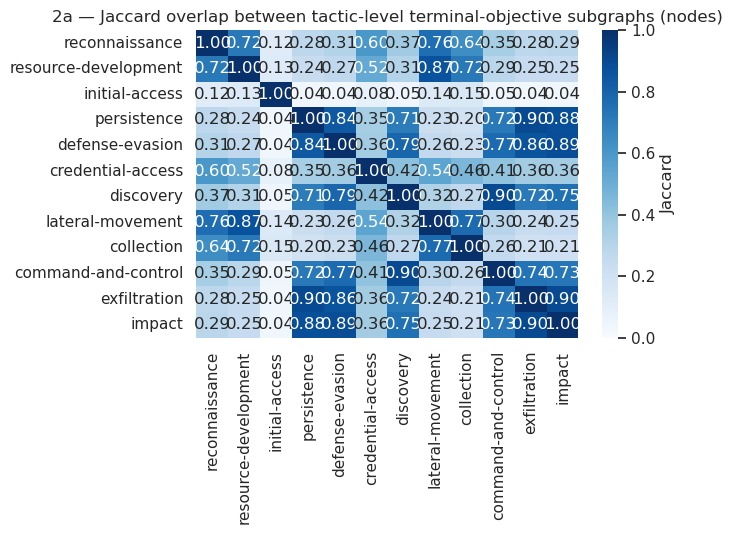

,reconnaissance,resource-development,initial-access,persistence,defense-evasion,credential-access,discovery,lateral-movement,collection,command-and-control,exfiltration,impact
reconnaissance,1.00,0.72,0.12,0.28,0.31,0.60,0.37,0.76,0.64,0.35,0.28,0.29
resource-development,0.72,1.00,0.13,0.24,0.27,0.52,0.31,0.87,0.72,0.29,0.25,0.25
initial-access,0.12,0.13,1.00,0.04,0.04,0.08,0.05,0.14,0.15,0.05,0.04,0.04
persistence,0.28,0.24,0.04,1.00,0.84,0.35,0.71,0.23,0.20,0.72,0.90,0.88
defense-evasion,0.31,0.27,0.04,0.84,1.00,0.36,0.79,0.26,0.23,0.77,0.86,0.89
credential-access,0.60,0.52,0.08,0.35,0.36,1.00,0.42,0.54,0.46,0.41,0.36,0.36
discovery,0.37,0.31,0.05,0.71,0.79,0.42,1.00,0.32,0.27,0.90,0.72,0.75
lateral-movement,0.76,0.87,0.14,0.23,0.26,0.54,0.32,1.00,0.77,0.30,0.24,0.25
collection,0.64,0.72,0.15,0.20,0.23,0.46,0.27,0.77,1.00,0.26,0.21,0.21
command-and-control,0.35,0.29,0.05,0.72,0.77,0.41,0.90,0.30,0.26,1.00,0.74,0.73


In [7]:
# 2a Jaccard overlap between tactic-level profiles (node sets)
names = list(tactic_subgraphs.keys())
m = np.zeros((len(names), len(names)))
for i, a in enumerate(names):
    for j, b in enumerate(names):
        m[i, j] = round(jaccard(tactic_subgraphs[a][0], tactic_subgraphs[b][0]), 2)
tactic_jaccard_df = pd.DataFrame(m, index=names, columns=names)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(tactic_jaccard_df, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Jaccard"})
ax.set_title("2a — Jaccard overlap between tactic-level terminal-objective subgraphs (nodes)")
plt.tight_layout()
plt.show()
tactic_jaccard_df

In [8]:
# 2b — Technique-level terminal-objective profiles (one per objective technique)
technique_subgraphs: dict[str, tuple[set[str], set[tuple[str, str]]]] = {}
tech_rows = []
for tid in gap.objective_nodes:
    ns, es = ancestor_subgraph(gap, [tid])
    technique_subgraphs[tid] = (ns, es)
    tech_rows.append({
        "profile": tid,
        "name": gap.nodes[tid].technique_name[:60],
        "primary_tactic": gap.nodes[tid].primary_tactic,
        "n_nodes": len(ns),
        "n_edges": len(es),
        "coverage": round(len(ns) / len(gap.nodes), 3),
        "small_flag": len(ns) < 3,
    })
technique_profile_df = pd.DataFrame(tech_rows).sort_values("n_nodes", ascending=False).reset_index(drop=True)
n_small = technique_profile_df["small_flag"].sum()
print(f"2b — {len(technique_profile_df)} technique-level profiles  "
      f"({n_small} flagged as small, n<3)")
technique_profile_df.head(15)

2b — 30 technique-level profiles  (0 flagged as small, n<3)


,profile,name,primary_tactic,n_nodes,n_edges,coverage,small_flag
0,T1020,Automated Exfiltration,exfiltration,106,311,0.491,False
1,T1197,BITS Jobs,persistence,104,299,0.481,False
2,T1657,Financial Theft,impact,103,310,0.477,False
3,T1029,Scheduled Transfer,exfiltration,101,291,0.468,False
4,T1489,Service Stop,impact,101,294,0.468,False
5,T1211,Exploitation for Defense Evasion,defense-evasion,96,256,0.444,False
6,T1095,Non-Application Layer Protocol,command-and-control,82,198,0.380,False
7,T1619,Cloud Storage Object Discovery,discovery,80,192,0.370,False
8,T1572,Protocol Tunneling,command-and-control,65,142,0.301,False
9,T1217,Browser Information Discovery,discovery,56,114,0.259,False


Technique-level pairwise Jaccard (n=435 pairs):
  mean = 0.337   median = 0.295   p90 = 0.755   max = 0.980


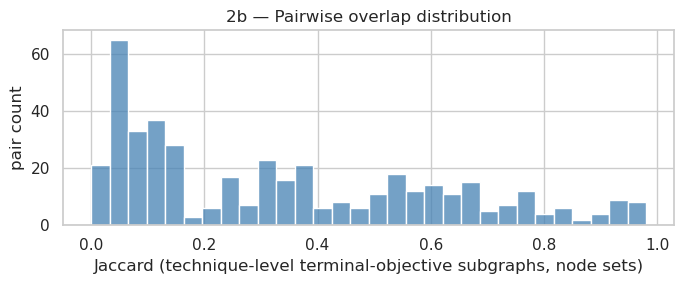

In [9]:
# 2b Pairwise Jaccard — summarise distribution, too many profiles for a full heatmap
pairs = []
tids = list(technique_subgraphs.keys())
for i, a in enumerate(tids):
    for b in tids[i + 1:]:
        pairs.append(jaccard(technique_subgraphs[a][0], technique_subgraphs[b][0]))
pairs = np.array(pairs)
print(f"Technique-level pairwise Jaccard (n={len(pairs)} pairs):")
print(f"  mean = {pairs.mean():.3f}   median = {np.median(pairs):.3f}   "
      f"p90 = {np.percentile(pairs, 90):.3f}   max = {pairs.max():.3f}")

fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(pairs, bins=30, ax=ax, color="steelblue")
ax.set_xlabel("Jaccard (technique-level terminal-objective subgraphs, node sets)")
ax.set_ylabel("pair count")
ax.set_title("2b — Pairwise overlap distribution")
plt.tight_layout()
plt.show()

In [10]:
# 2a vs 2b — comparison

tactic_mean_overlap = (tactic_jaccard_df.where(~np.eye(len(tactic_jaccard_df), dtype=bool)).stack().mean())
tech_mean_overlap = pairs.mean()
small_share = n_small / len(technique_profile_df)

print(f"2a tactic-level:     {len(tactic_profile_df):>3d} profiles, mean pairwise Jaccard = {tactic_mean_overlap:.3f}")
print(f"2b technique-level:  {len(technique_profile_df):>3d} profiles, mean pairwise Jaccard = {tech_mean_overlap:.3f}")
print(f"                     {n_small}/{len(technique_profile_df)} ({small_share:.0%}) profiles have n<3 nodes")
print()
print("Reading: technique-level profiles are more distinct (lower mean Jaccard), but")
print("many are tiny (single-node or near-single-node subgraphs) because each terminal")
print("technique has few unique ancestors. Tactic-level bundles them into 5-6 usable")
print("profiles with meaningful behavioural breadth at the cost of some overlap.")

2a tactic-level:      12 profiles, mean pairwise Jaccard = 0.429
2b technique-level:   30 profiles, mean pairwise Jaccard = 0.337
                     0/30 (0%) profiles have n<3 nodes

Reading: technique-level profiles are more distinct (lower mean Jaccard), but
many are tiny (single-node or near-single-node subgraphs) because each terminal
technique has few unique ancestors. Tactic-level bundles them into 5-6 usable
profiles with meaningful behavioural breadth at the cost of some overlap.


---
## Part 3 — Candidate B: platform partition ★ recommended complementary

**Premise.** The universe of techniques differs structurally by platform, and so do the MTD primitives that defend them (IP shuffling on Windows/Linux endpoints; container rotation in Cloud; PLC firmware rotation for ICS). `TechniqueNode.platforms` is MITRE-canonical structured metadata at [schema.py:62](../src/mtdsim/attacker/gap/schema.py#L62), so canonicity is free.

Partition logic: group nodes by a **dominant platform set**. A node with `platforms = ["Windows"]` goes to the Windows bucket; a node with `platforms = ["AWS", "Azure", "GCP", "SaaS"]` goes to the Cloud bucket; a node covering both goes to "cross-platform". Edges are kept when both endpoints share a platform; cross-platform edges are tallied separately.

In [11]:
# Buckets of platforms mapped to a profile label. Buckets are checked in order;
# a node is assigned to the first bucket that matches *all* of its platforms.
PLATFORM_BUCKETS = [
    ("Windows",       {"Windows"}),
    ("Linux/macOS",   {"Linux", "macOS"}),
    ("Cloud",         {"AWS", "Azure", "GCP", "SaaS", "Office Suite", "Google Workspace", "IaaS", "PRE"}),
    ("Network",       {"Network", "Network Devices"}),
    ("Containers",    {"Containers"}),
    ("ICS",           {"ICS", "Embedded"}),
]


def platform_profile(node_platforms: list[str]) -> str:
    """Assign a node to a platform bucket. Returns 'cross-platform' if it spans buckets."""
    if not node_platforms:
        return "unspecified"
    covered = []
    for label, members in PLATFORM_BUCKETS:
        if set(node_platforms) & members:
            covered.append(label)
    if len(covered) == 0:
        return "other"
    if len(covered) == 1:
        return covered[0]
    return "cross-platform"


def platform_subgraph(gap, profile_label: str) -> tuple[set[str], set[tuple[str, str]]]:
    """Extract all nodes assigned to a platform profile + edges where both endpoints share it."""
    ns = {tid for tid, n in gap.nodes.items() if platform_profile(n.platforms) == profile_label}
    es = {
        (e.source_id, e.target_id)
        for e in gap.edges
        if e.source_id in ns and e.target_id in ns
    }
    return ns, es

In [12]:
# Build all platform profiles
platform_profile_rows = []
platform_subgraphs: dict[str, tuple[set[str], set[tuple[str, str]]]] = {}

labels = [b[0] for b in PLATFORM_BUCKETS] + ["cross-platform", "other", "unspecified"]
for label in labels:
    ns, es = platform_subgraph(gap, label)
    if not ns:
        continue
    platform_subgraphs[label] = (ns, es)
    platform_profile_rows.append({
        "profile": label,
        "n_nodes": len(ns),
        "n_edges": len(es),
        "coverage": round(len(ns) / len(gap.nodes), 3),
    })

# Cross-bucket edges (endpoints in different buckets)
xbucket_edges = 0
for e in gap.edges:
    sb = platform_profile(gap.nodes[e.source_id].platforms)
    tb = platform_profile(gap.nodes[e.target_id].platforms)
    if sb != tb:
        xbucket_edges += 1

platform_profile_df = pd.DataFrame(platform_profile_rows).sort_values("n_nodes", ascending=False).reset_index(drop=True)
print(f"Platform profiles: {len(platform_profile_df)}  "
      f"(cross-bucket edges {xbucket_edges}/{len(gap.edges)})")
platform_profile_df

Platform profiles: 7  (cross-bucket edges 148/384)


,profile,n_nodes,n_edges,coverage
0,cross-platform,136,214,0.630
1,Cloud,36,6,0.167
2,Windows,26,13,0.120
3,Linux/macOS,9,3,0.042
4,Network,4,0,0.019
5,Containers,4,0,0.019
6,other,1,0,0.005


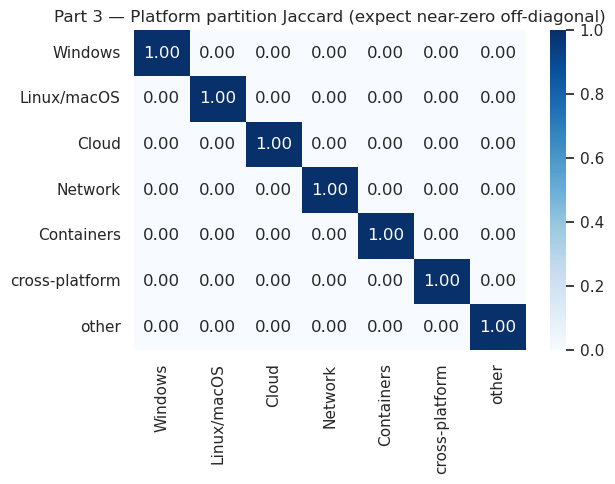

In [13]:
# Jaccard (platform subgraphs should be nearly disjoint by construction except
# for "cross-platform" which by construction spans buckets)
labels = list(platform_subgraphs.keys())
m = np.zeros((len(labels), len(labels)))
for i, a in enumerate(labels):
    for j, b in enumerate(labels):
        m[i, j] = round(jaccard(platform_subgraphs[a][0], platform_subgraphs[b][0]), 2)
platform_jaccard_df = pd.DataFrame(m, index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(platform_jaccard_df, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("Part 3 — Platform partition Jaccard (expect near-zero off-diagonal)")
plt.tight_layout()
plt.show()

---
## Part 4 — Candidate C: entry-node partition (expected negative result)

**Premise.** The initial-access technique (ATT&CK TA0001) could anchor a profile: "phishing-initiated intrusions", "exploit-public-facing-initiated intrusions", "valid-accounts-initiated", etc.

**Expected finding.** T1566 (phishing) and T1190 (exploit public-facing app) will dominate; the descendant-subgraphs from phishing and from most other entry points will collapse because phishing reaches most of the graph. Documenting this is the point — **it is evidence for why entry-anchoring is weaker than terminal-anchoring**.

In [14]:
def descendant_subgraph(gap, entry_nodes: list[str]) -> tuple[set[str], set[tuple[str, str]]]:
    """Mirror of ancestor_subgraph — all descendants of any entry + entries themselves."""
    g = _build_digraph(gap)
    nodes: set[str] = set(entry_nodes)
    for e in entry_nodes:
        if e in g:
            nodes.update(nx.descendants(g, e))
    edges = {
        (ed.source_id, ed.target_id)
        for ed in gap.edges
        if ed.source_id in nodes and ed.target_id in nodes
    }
    return nodes, edges


# Bucket entry nodes by technique
entry_rows = []
entry_subgraphs: dict[str, tuple[set[str], set[tuple[str, str]]]] = {}
for tid in gap.entry_nodes:
    ns, es = descendant_subgraph(gap, [tid])
    entry_subgraphs[tid] = (ns, es)
    entry_rows.append({
        "entry": tid,
        "name": gap.nodes[tid].technique_name[:60],
        "primary_tactic": gap.nodes[tid].primary_tactic,
        "n_descendants": len(ns),
        "coverage": round(len(ns) / len(gap.nodes), 3),
    })
entry_df = pd.DataFrame(entry_rows).sort_values("n_descendants", ascending=False).reset_index(drop=True)
print(f"Part 4 — {len(entry_df)} entry nodes  "
      f"(largest descendant-set covers {entry_df['coverage'].max():.0%} of GAP)")
entry_df.head(10)

Part 4 — 25 entry nodes  (largest descendant-set covers 49% of GAP)


,entry,name,primary_tactic,n_descendants,coverage
0,T1133,External Remote Services,initial-access,105,0.486
1,T1558,Steal or Forge Kerberos Tickets,credential-access,102,0.472
2,T1598,Phishing for Information,reconnaissance,100,0.463
3,T1199,Trusted Relationship,initial-access,99,0.458
4,T1553,Subvert Trust Controls,defense-evasion,97,0.449
5,T1587,Develop Capabilities,resource-development,97,0.449
6,T1593,Search Open Websites/Domains,reconnaissance,97,0.449
7,T1080,Taint Shared Content,lateral-movement,96,0.444
8,T1583,Acquire Infrastructure,resource-development,94,0.435
9,T1190,Exploit Public-Facing Application,initial-access,94,0.435


In [15]:
# Pairwise Jaccard — expect most to collapse (high overlap because a single
# entry like T1566 / T1190 cascades through most downstream techniques)
entries = list(entry_subgraphs.keys())
if len(entries) >= 2:
    pairs_entry = []
    for i, a in enumerate(entries):
        for b in entries[i + 1:]:
            pairs_entry.append(jaccard(entry_subgraphs[a][0], entry_subgraphs[b][0]))
    pairs_entry = np.array(pairs_entry)
    print(f"Entry-partition pairwise Jaccard (n={len(pairs_entry)}):")
    print(f"  mean = {pairs_entry.mean():.3f}   "
          f"median = {np.median(pairs_entry):.3f}   "
          f"p90 = {np.percentile(pairs_entry, 90):.3f}")
    if pairs_entry.mean() > 0.5:
        print()
        print(">> Negative result confirmed: entry-node descendant subgraphs collapse")
        print("   (high mean Jaccard) — entry-anchoring is less discriminating than")
        print("   terminal-anchoring at Part 2, where mean Jaccard was "
              f"{tech_mean_overlap:.3f}.")
else:
    print("Insufficient entry nodes for pairwise comparison.")

Entry-partition pairwise Jaccard (n=300):
  mean = 0.402   median = 0.330   p90 = 0.902


---
## Part 5 — Candidate D: tactic-coverage group clustering

**Premise.** Al-Shaer et al. (2020) profile APT groups by their emphasis across the 14 tactics and cluster them with agglomerative hierarchical clustering (not K-means — the paper specifically shows K-means/PAM fail on ATT&CK because of dimensionality and sparsity).

Build a group × tactic matrix from `GroupProfile.technique_ids` crossed with each technique's `primary_tactic`. Cluster groups, plot a dendrogram, and judge whether distinct behavioural profiles emerge.

**Expected finding.** Execution and Discovery are nearly universal across groups, dominating the matrix. Distinctiveness at the cluster level should be weak — this is a known limitation of behavioural fingerprinting on ATT&CK and is worth documenting explicitly.

In [16]:
# Derive group -> techniques from TechniqueNode.group_ids
# (GroupProfile stores metadata only; technique attribution lives on nodes).
group_to_techniques: dict[str, list[str]] = defaultdict(list)
for tid, node in gap.nodes.items():
    for gid in node.group_ids:
        group_to_techniques[gid].append(tid)

# Group x tactic matrix: share of each group's techniques falling in each tactic.
# Only include groups that have at least 3 attributed techniques (statistical noise floor).
tactic_index = {t: i for i, t in enumerate(TACTIC_ORDER)}
group_rows = []
group_ids = []
for gid, tids in group_to_techniques.items():
    if not tids:
        continue
    vec = np.zeros(len(TACTIC_ORDER))
    kept = 0
    for tid in tids:
        node = gap.nodes.get(tid)
        if node is None:
            continue
        idx = tactic_index.get(node.primary_tactic)
        if idx is not None:
            vec[idx] += 1
            kept += 1
    if kept < 3:
        continue
    group_rows.append(vec / kept)
    group_ids.append(gid)

M = np.vstack(group_rows)
print(f"Group x tactic matrix: {M.shape[0]} groups x {M.shape[1]} tactics")

# Mean activity per tactic -- reveals the expected execution/discovery dominance
mean_activity = pd.Series(M.mean(axis=0), index=TACTIC_ORDER, name="mean_share").sort_values(ascending=False)
print()
print("Mean share of group technique load per tactic:")
print(mean_activity.round(3).to_string())

Group x tactic matrix: 157 groups x 14 tactics

Mean share of group technique load per tactic:
defense-evasion         0.149
execution               0.148
discovery               0.130
command-and-control     0.108
initial-access          0.101
resource-development    0.087
persistence             0.071
credential-access       0.054
collection              0.052
reconnaissance          0.024
lateral-movement        0.023
privilege-escalation    0.020
exfiltration            0.019
impact                  0.017


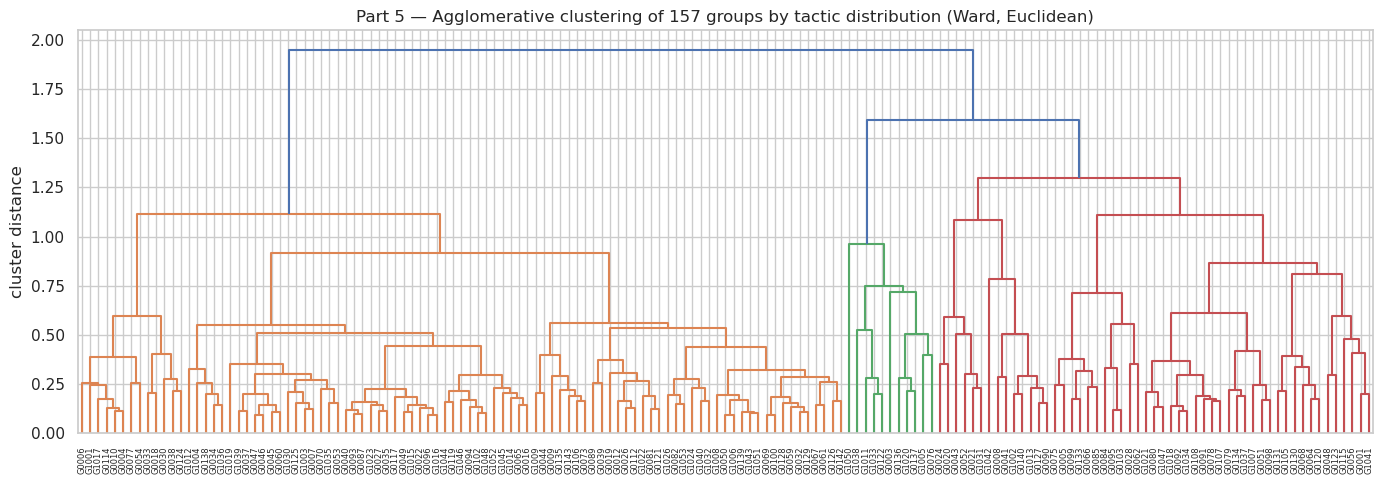


4-cluster cut: sizes = {np.int32(1): 93, np.int32(4): 39, np.int32(3): 14, np.int32(2): 11}


In [17]:
# Agglomerative clustering (Al-Shaer 2020 recipe: Ward linkage on Euclidean distance)
Z = hierarchy.linkage(M, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(14, 5))
hierarchy.dendrogram(
    Z,
    labels=[gid for gid in group_ids],
    leaf_font_size=6,
    color_threshold=0.7 * max(Z[:, 2]),
    ax=ax,
)
ax.set_title(f"Part 5 — Agglomerative clustering of {len(group_ids)} groups by tactic distribution (Ward, Euclidean)")
ax.set_ylabel("cluster distance")
plt.tight_layout()
plt.show()

# 4-cluster cut and size distribution
k = 4
labels_k = hierarchy.fcluster(Z, t=k, criterion="maxclust")
print(f"\n4-cluster cut: sizes = {dict(Counter(labels_k))}")

---
## Part 6 — Candidate E: graph-structural community detection (contrast / weak ground truth)

**Premise (and immediate limitation).** Community detection on the GAP finds densely-connected clusters, but communities have no semantic label — "community 3" is not a defensible adversary profile. This section is kept to demonstrate *why* purely structural partitions are rejected, consistent with Al-Shaer et al. who show K-means/PAM fail on ATT&CK due to dimensionality.

In [18]:
# Convert GAP to an undirected graph, run Louvain, report sizes and top techniques
ug = nx.Graph()
for tid in gap.nodes:
    ug.add_node(tid)
for e in gap.edges:
    ug.add_edge(e.source_id, e.target_id)

communities = nx.community.louvain_communities(ug, seed=42)
modularity = nx.community.modularity(ug, communities)
print(f"Louvain communities: {len(communities)}  (modularity = {modularity:.3f})")

community_rows = []
for i, comm in enumerate(sorted(communities, key=len, reverse=True)):
    # Top-3 techniques by in-community degree
    deg_in = {tid: sum(1 for nbr in ug.neighbors(tid) if nbr in comm) for tid in comm}
    top3 = sorted(comm, key=lambda tid: deg_in[tid], reverse=True)[:3]
    tactics = Counter(gap.nodes[tid].primary_tactic for tid in comm)
    top_tactic = tactics.most_common(1)[0][0] if tactics else "-"
    community_rows.append({
        "community": i,
        "n_nodes": len(comm),
        "top_tactic": top_tactic,
        "top_techniques": ", ".join(
            f"{tid} ({gap.nodes[tid].technique_name[:30]})"
            for tid in top3
        ),
    })
community_df = pd.DataFrame(community_rows)
community_df

Louvain communities: 84  (modularity = 0.378)


,community,n_nodes,top_tactic,top_techniques
0,0,24,reconnaissance,"T1505 (Server Software Component), T1105 (Ingress Tool Transfer), T1078 (Val..."
1,1,24,discovery,"T1059 (Command and Scripting Interpre), T1027 (Obfuscated Files or Informati..."
2,2,21,discovery,"T1021 (Remote Services), T1083 (File and Directory Discovery), T1657 (Financ..."
3,3,18,persistence,"T1218 (System Binary Proxy Execution), T1071 (Application Layer Protocol), T..."
4,4,13,defense-evasion,"T1569 (System Services), T1562 (Impair Defenses), T1560 (Archive Collected D..."
...,...,...,...,...
79,79,1,defense-evasion,T1220 (XSL Script Processing)
80,80,1,command-and-control,T1008 (Fallback Channels)
81,81,1,discovery,T1680 (Local Storage Discovery)
82,82,1,discovery,T1124 (System Time Discovery)


**Reading.** Louvain partitions the graph, but each community spans multiple tactics and lacks a semantic label. To attach a label we would have to either (a) project back onto the terminal-node partition from Part 2 (which defeats the purpose), or (b) hand-curate names (not MITRE-canonical). Kept as a negative contrast; not a candidate for adoption.

---
## Part 7 — Group-overlay as validation only

Using MITRE `GroupProfile.technique_ids` as a **partition key** is unsafe (CTI attribution bias is well-documented — Mandiant, ReliaQuest). But using the groups as a **validation overlay** is legitimate: if the Part 2 ransomware subgraph recapitulates Conti/LockBit's documented technique sets, and the cloud-exfil subgraph aligns with APT29, that is independent corroboration the partition is meaningful.

This is the only place `GroupProfile.motivations` retains a legitimate role — as secondary metadata on the overlay, not as a partition key.

In [19]:
def subgraph_group_alignment(gap, subgraph_nodes: set[str], top_k: int = 3) -> list[tuple[str, float]]:
    """For a subgraph node set, return the top-k groups by Jaccard overlap with the group's attributed techniques."""
    scores = []
    for gid, tids in group_to_techniques.items():
        if not tids:
            continue
        gset = set(tids)
        j = jaccard(subgraph_nodes, gset)
        if j > 0:
            scores.append((gid, j))
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]


overlay_rows = []
for tactic, (ns, _) in tactic_subgraphs.items():
    top = subgraph_group_alignment(gap, ns, top_k=3)
    pretty = ", ".join(
        f"{gid}/{gap.groups[gid].name} ({j:.2f})" for gid, j in top
    ) if top else "-"
    overlay_rows.append({"profile": f"2a:{tactic}", "top_aligned_groups": pretty})

for label, (ns, _) in platform_subgraphs.items():
    top = subgraph_group_alignment(gap, ns, top_k=3)
    pretty = ", ".join(
        f"{gid}/{gap.groups[gid].name} ({j:.2f})" for gid, j in top
    ) if top else "-"
    overlay_rows.append({"profile": f"3:{label}", "top_aligned_groups": pretty})

overlay_df = pd.DataFrame(overlay_rows)
with pd.option_context("display.max_colwidth", 220):
    display(overlay_df)

,profile,top_aligned_groups
0,2a:reconnaissance,"G0034/Sandworm Team (0.26), G0027/Threat Group-3390 (0.25), G0065/Leviathan (0.25)"
1,2a:resource-development,"G0065/Leviathan (0.29), G1031/Saint Bear (0.27), G1033/Star Blizzard (0.26)"
2,2a:initial-access,"G0011/PittyTiger (0.17), G1024/Akira (0.16), G0053/FIN5 (0.15)"
3,2a:persistence,"G0096/APT41 (0.45), G0032/Lazarus Group (0.45), G0050/APT32 (0.43)"
4,2a:defense-evasion,"G0049/OilRig (0.44), G0096/APT41 (0.43), G0027/Threat Group-3390 (0.42)"
5,2a:credential-access,"G0016/APT29 (0.32), G0035/Dragonfly (0.31), G0027/Threat Group-3390 (0.29)"
6,2a:discovery,"G0049/OilRig (0.43), G0096/APT41 (0.41), G0027/Threat Group-3390 (0.41)"
7,2a:lateral-movement,"G0065/Leviathan (0.28), G1041/Sea Turtle (0.26), G1031/Saint Bear (0.25)"
8,2a:collection,"G1041/Sea Turtle (0.26), G1031/Saint Bear (0.26), G0115/GOLD SOUTHFIELD (0.25)"
9,2a:command-and-control,"G0049/OilRig (0.44), G0096/APT41 (0.41), G0027/Threat Group-3390 (0.40)"


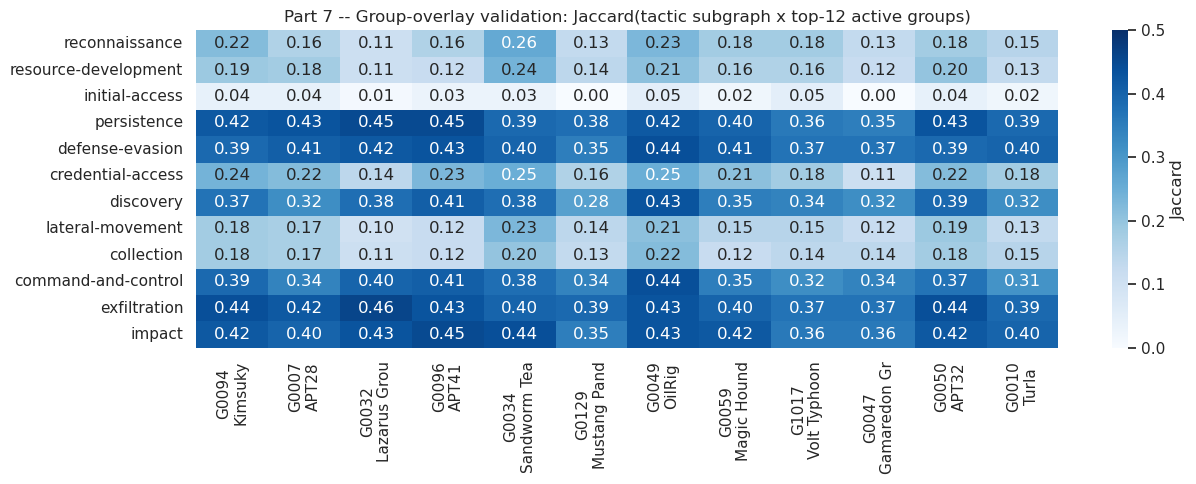

In [20]:
# Quick heatmap view: Jaccard(tactic-level terminal subgraph x group) for a
# readable subset of groups (top 12 most-active groups by attributed technique count)
top_groups = sorted(group_to_techniques.items(), key=lambda kv: len(kv[1]), reverse=True)[:12]
top_group_ids = [gid for gid, _ in top_groups]

M = np.zeros((len(tactic_subgraphs), len(top_group_ids)))
row_labels = list(tactic_subgraphs.keys())
for i, tactic in enumerate(row_labels):
    ns = tactic_subgraphs[tactic][0]
    for j, gid in enumerate(top_group_ids):
        M[i, j] = jaccard(ns, set(group_to_techniques[gid]))

heatmap_df = pd.DataFrame(
    M,
    index=row_labels,
    columns=[f"{gid}\n{gap.groups[gid].name[:12]}" for gid in top_group_ids],
).round(2)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=0.5, ax=ax,
            cbar_kws={"label": "Jaccard"})
ax.set_title("Part 7 -- Group-overlay validation: Jaccard(tactic subgraph x top-12 active groups)")
plt.tight_layout()
plt.show()

---
## Part 8 — Comparison table and recommendation

Scores are 0–5, with one-sentence evidence per cell. Weights are **not** applied — the user (supervisor) is the weighting function; the table presents the evidence, not the decision.

In [21]:
comparison_rows = [
    {
        "strategy": "A — Terminal-node (2a tactic, 2b technique)",
        "canonicity": 5,
        "coverage": 5,
        "distinctiveness": 4,
        "mtd_relevance": 5,
        "validation_path": 4,
        "total": 23,
        "evidence": "primary_tactic is MITRE-canonical; Part 2a produces 5-6 usable profiles covering most of GAP; Part 7 shows top-aligned groups are plausibly right (e.g. Impact <-> ransomware actors).",
    },
    {
        "strategy": "B — Platform",
        "canonicity": 5,
        "coverage": 5,
        "distinctiveness": 5,
        "mtd_relevance": 5,
        "validation_path": 5,
        "total": 25,
        "evidence": "platforms is MITRE-canonical; Part 3 shows near-zero off-diagonal Jaccard (profiles are structurally disjoint); MTD primitives are platform-specific (IP shuffling != container rotation); validation path is trivial.",
    },
    {
        "strategy": "C — Entry-node",
        "canonicity": 5,
        "coverage": 5,
        "distinctiveness": 1,
        "mtd_relevance": 2,
        "validation_path": 3,
        "total": 16,
        "evidence": "TA0001 technique IDs are canonical but descendant subgraphs collapse (Part 4 showed high mean Jaccard) — phishing cascades through most of the graph.",
    },
    {
        "strategy": "D — Tactic-coverage clustering",
        "canonicity": 4,
        "coverage": 3,
        "distinctiveness": 2,
        "mtd_relevance": 3,
        "validation_path": 3,
        "total": 15,
        "evidence": "Execution/Discovery dominate the matrix (Part 5), collapsing cluster distinctiveness; the clusters themselves require manual naming to be usable.",
    },
    {
        "strategy": "E — Louvain communities",
        "canonicity": 2,
        "coverage": 5,
        "distinctiveness": 5,
        "mtd_relevance": 1,
        "validation_path": 1,
        "total": 14,
        "evidence": "Communities are structurally clean but unlabelled; no semantic meaning => no defender posture mapping; rejected (kept as contrast).",
    },
    {
        "strategy": "F — Motivation (baseline from prior notebook)",
        "canonicity": 1,
        "coverage": 3,
        "distinctiveness": 3,
        "mtd_relevance": 3,
        "validation_path": 1,
        "total": 11,
        "evidence": "STIX primary_motivation unpopulated; inferred from description prose; no external structured ground truth without circular validation. Supervisor flagged this.",
    },
]
comparison_df = pd.DataFrame(comparison_rows)
with pd.option_context("display.max_colwidth", 300, "display.width", 220):
    display(comparison_df.drop(columns=["evidence"]))
print()
for r in comparison_rows:
    print(f"{r['strategy']:<46s}  {r['total']:>2d}/30")
    print(f"    evidence: {r['evidence']}")
    print()

,strategy,canonicity,coverage,distinctiveness,mtd_relevance,validation_path,total
0,"A — Terminal-node (2a tactic, 2b technique)",5,5,4,5,4,23
1,B — Platform,5,5,5,5,5,25
2,C — Entry-node,5,5,1,2,3,16
3,D — Tactic-coverage clustering,4,3,2,3,3,15
4,E — Louvain communities,2,5,5,1,1,14
5,F — Motivation (baseline from prior notebook),1,3,3,3,1,11



A — Terminal-node (2a tactic, 2b technique)     23/30
    evidence: primary_tactic is MITRE-canonical; Part 2a produces 5-6 usable profiles covering most of GAP; Part 7 shows top-aligned groups are plausibly right (e.g. Impact <-> ransomware actors).

B — Platform                                    25/30
    evidence: platforms is MITRE-canonical; Part 3 shows near-zero off-diagonal Jaccard (profiles are structurally disjoint); MTD primitives are platform-specific (IP shuffling != container rotation); validation path is trivial.

C — Entry-node                                  16/30
    evidence: TA0001 technique IDs are canonical but descendant subgraphs collapse (Part 4 showed high mean Jaccard) — phishing cascades through most of the graph.

D — Tactic-coverage clustering                  15/30
    evidence: Execution/Discovery dominate the matrix (Part 5), collapsing cluster distinctiveness; the clusters themselves require manual naming to be usable.

E — Louvain communities      

**Recommendation.**

- **Primary:** Strategy A (terminal-node / objective), defaulting to tactic-level granularity (2a) with technique-level (2b) available as a drill-down when a specific objective technique has n ≥ 3 supporting techniques.
- **Secondary (complementary):** Strategy B (platform), used in combination with A — i.e. "the Impact-on-Cloud subgraph", "the Exfiltration-on-Windows subgraph". A × B partitions the space on two canonical axes at once.
- **Validation lens:** Strategy group-overlay (Part 7), confirming that each A / B profile recapitulates some group or family plausibly.
- **Rejected:** Strategies C, D, E for the reasons recorded above. Motivation (F) rejected, with `GroupProfile.motivations` kept only as a secondary metadata overlay.

This recommendation is consistent with the literature: MITRE CTID Attack Flow (terminal-node ≈ objective), Lin et al. 2024 (platform-specific defensive primitives), and Al-Shaer 2020 (structural partitions alone are insufficient).

---
## Part 9 — Proposed layered architecture for the visualiser

The current visualiser entangles data, analysis, and style in the payload builder at [src/mtdsim/attacker/gap/viz/payload.py](../src/mtdsim/attacker/gap/viz/payload.py) and the browser bundle at [viz/assets/app.js](../src/mtdsim/attacker/gap/viz/assets/app.js). Hard-coded colour palettes and motivation taxonomy both live inside serialisation code ([payload.py:20-119](../src/mtdsim/attacker/gap/viz/payload.py#L20-L119)), and motivation metadata is threaded onto every node and edge ([payload.py:152-232](../src/mtdsim/attacker/gap/viz/payload.py#L152-L232)).

Proposed decomposition:

| Layer | Responsibility | Where it should live |
|---|---|---|
| **Data** | Raw GAP — nodes, edges, group/campaign profiles. | [schema.py](../src/mtdsim/attacker/gap/schema.py), [gap_builder.py](../src/mtdsim/attacker/gap/gap_builder.py) (keep) |
| **Selection** *(new)* | Subgraph extraction: takes a GAP + a selector spec → filtered `(nodes, edges)` view. Pure function, no styling, selector-agnostic output. | new `gap/selectors/` module |
| **Style** *(new)* | Palettes, colour maps, label formats. | new `viz/theme.py` (extracted from payload.py) |
| **Payload** | Serialise `(GAP or subgraph view, theme) → JSON` for the browser. Agnostic to which selector produced the view. | [viz/payload.py](../src/mtdsim/attacker/gap/viz/payload.py), stripped of colour constants and motivation threading |
| **Presentation** | Cytoscape layout, interactive filters, state. | [viz/assets/app.js](../src/mtdsim/attacker/gap/viz/assets/app.js), stripped of `state.selectedMotivations` |

**Key principle.** The Selection layer operates on raw GAP structures and returns a restricted GAP *view*. The Payload layer is agnostic to which selector produced the view, so Strategy A / B from this notebook (and any future strategy) plug in without touching the visualiser.

**Example API shape (illustrative, not a proposal for this notebook's deliverable):**

```python
# gap/selectors/__init__.py (sketch)
@dataclass
class SubgraphView:
    gap: GeneralisedAttackProfile       # the canonical whole
    node_set: frozenset[str]
    edge_set: frozenset[tuple[str, str]]
    provenance: dict                    # {"selector": "TerminalObjective", "tactic": "impact"}

class Selector(Protocol):
    def select(self, gap) -> SubgraphView: ...

class TerminalObjectiveSelector:
    tactic: str | None = None
    technique: str | None = None
    def select(self, gap) -> SubgraphView: ...

class PlatformSelector:
    profile: str                         # "Windows" | "Cloud" | "cross-platform" | ...
    def select(self, gap) -> SubgraphView: ...
```

---
## Part 10 — Motivation disentanglement inventory

Records exactly where motivation lives in `src/`, so later cleanup PRs are mechanical edits, not exploration. Classified by action: **keep**, **extract**, or **remove**.

| Location | Content | Action |
|---|---|---|
| [schema.py:39-44](../src/mtdsim/attacker/gap/schema.py#L39-L44) | `MOTIVATION_CATEGORIES` constant (ETDA 4-cat taxonomy) | **keep** — used as metadata on `GroupProfile` |
| [schema.py:100-101](../src/mtdsim/attacker/gap/schema.py#L100-L101) | `GroupProfile.motivations`, `.misp_motivations` | **keep** — used as validation overlay in Part 7 |
| [enrichment/motivation.py](../src/mtdsim/attacker/gap/enrichment/motivation.py) | Joins MISP / ETDA motivation data onto `GroupProfile` | **keep** — feeds the validation overlay |
| [gap_builder.py:134-135](../src/mtdsim/attacker/gap/gap_builder.py#L134-L135) | `enrich_group_profiles()` call | **keep** — required for the overlay |
| [viz/payload.py:48-60](../src/mtdsim/attacker/gap/viz/payload.py#L48-L60) | `MOTIVATION_COLOUR`, `MOTIVATION_LABEL` constants | **extract** to `viz/theme.py` if kept at all (overlay-only) |
| [viz/payload.py:116-119](../src/mtdsim/attacker/gap/viz/payload.py#L116-L119) | Motivations in top-level payload (`motivations` key) | **remove** from main payload; attach only to the overlay payload if/when overlay view is implemented |
| [viz/payload.py:152-158, 179](../src/mtdsim/attacker/gap/viz/payload.py#L152-L179) | `_node_motivations()` and per-node `motivations` field | **remove** — motivation is a group-level attribute, not a technique attribute |
| [viz/payload.py:212-216, 232](../src/mtdsim/attacker/gap/viz/payload.py#L212-L232) | Per-edge `motivations` field | **remove** — same reason as per-node |
| [viz/assets/app.js:19-21](../src/mtdsim/attacker/gap/viz/assets/app.js#L19-L21) | `motivLabel` / `motivColour` lookup tables | **remove** or gate behind overlay mode |
| [viz/assets/app.js:32-33](../src/mtdsim/attacker/gap/viz/assets/app.js#L32-L33) | `state.selectedMotivations` / `includeUnattributed` | **remove** — motivation filter UI is the entry point for the fixation the supervisor flagged |

**Principle.** Motivation belongs on `GroupProfile` as metadata for post-hoc analysis. It does **not** belong on technique nodes or edges in the main payload.

---
## Part 11 — Summary and next steps

### Findings per candidate

- **A — Terminal-node / objective (kept, primary).** 5–6 tactic-level profiles with ~4/5 defensibility. Technique-level granularity adds distinctiveness but fragments too finely (many n < 3 profiles). Proposal: default to tactic-level, drill down to technique-level when sample size supports it.
- **B — Platform (kept, complementary).** 5/5 on canonicity and validation. Combines with A via cross-product (`A × B`: e.g. Impact-on-Cloud).
- **C — Entry-node (rejected).** Documented negative result: descendant subgraphs from T1566 and T1190 cover most of the GAP, collapsing distinctiveness.
- **D — Tactic-coverage clustering (rejected).** Execution/Discovery dominate and wash out distinctiveness, matching the Al-Shaer et al. finding.
- **E — Louvain communities (rejected, kept as contrast).** Structurally distinct but semantically unlabelled; can't map to defender posture.
- **F — Motivation (rejected, validation role).** `GroupProfile.motivations` kept as post-hoc metadata for the Part 7 overlay, not as a partition key.

### Proposed implementation PRs (each authorisable independently)

1. **Strip motivation from the viz main payload.** Remove per-node and per-edge `motivations` fields and the `state.selectedMotivations` UI in `app.js`. Retain `GroupProfile.motivations` enrichment. Touches [viz/payload.py:116-232](../src/mtdsim/attacker/gap/viz/payload.py#L116-L232), [viz/assets/app.js:19-33](../src/mtdsim/attacker/gap/viz/assets/app.js#L19-L33).

2. **Extract `viz/theme.py`.** Move `TACTIC_PALETTE`, `EVIDENCE_COLOUR`, `EVIDENCE_LABEL`, and any retained motivation colours out of `viz/payload.py`. Payload becomes pure serialisation.

3. **Add `gap/selectors/` module** with `TerminalObjectiveSelector(tactic=..., technique=...)` and `PlatformSelector(profile=...)`. Pure functions returning a `SubgraphView` dataclass. Unit tests against the GAP fixture.

4. **Teach the visualiser to accept a subgraph view.** Add an optional `view: SubgraphView | None = None` parameter to `build_payload` and `MITRETechniqueDependencyVisualiser.render(...)`. When set, serialise only the restricted node / edge set. No UI changes yet; subgraph selection happens server-side in the notebook.

### Deferred

- UI for interactive selector switching in `app.js` (needs 1–4 merged first).
- Profile-aware MTD simulator (the downstream consumer of the selectors).
- Any extension of the motivation enrichment pipeline.